##TAREA 3
#Dashboards en Python


#Integrantes del grupo:

*   Eukaris Blanco
*   Laura Castillo
*   Jorge reyes
*   Karen Sánchez

# BACKEND

In [2]:
import os
import urllib.request
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler

direccion = "https://data.cdc.gov/api/views/hn4x-zwk7/rows.csv?accessType=DOWNLOAD"
archivo_original = "brfss_nutrition_raw.csv"
archlimpieza_datos = "brfss_nutrition_clean.csv"

def descargar_datos():
    if not os.path.exists(archivo_original):
        print("Se descargará el dataset")
        urllib.request.urlretrieve(direccion, archivo_original)
        print("El archivo fue descargado")
    else:
        print("El archivo ya habia sido descargado")

def backend():
    df = pd.read_csv(archivo_original, low_memory=False)
    print(f"El archivo tiene (filas, columnas): {df.shape}")

    df.columns = df.columns.str.strip()
    columnas = {
        'YearStart': ['YearStart', 'yearstart'],
        'LocationAbbr': ['LocationAbbr', 'locationabbr'],
        'LocationDesc': ['LocationDesc', 'locationdesc'],
        'Question': ['Question', 'question'],
        'Data_Value': ['Data_Value', 'DataValue', 'data_value'],
        'Low_Confidence_Limit': ['Low_Confidence_Limit', 'LowConfidenceLimit', 'low_confidence_limit'],
        'High_Confidence_Limit': ['High_Confidence_Limit', 'HighConfidenceLimit', 'high_confidence_limit'],
        'StratificationCategory1': ['StratificationCategory1', 'StratificationCategory_1', 'stratificationcategory1'],
        'Stratification1': ['Stratification1', 'Stratification_1', 'stratification1'],
    }

    Nombre_columnas = {}
    for nom_columna, alternativas in columnas.items():
        col_encontrada = next((alt for alt in alternativas if alt in df.columns), None)
        if col_encontrada:
            Nombre_columnas[nom_columna] = col_encontrada
        else:
            raise KeyError(f"No se encontró variante para la columna: '{nom_columna}'")

    columnas_interes = list(Nombre_columnas.values())
    df_filtered = df[columnas_interes].copy()
    df_filtered.columns = list(Nombre_columnas.keys())

    duplicados = df_filtered.shape[0]
    df_filtered = df_filtered.drop_duplicates()
    print(f"Duplicados eliminados: {duplicados - df_filtered.shape[0]} filas removidas.")

    print("\nAnalizando valores nulos en cada columna antes de realizar limpieza:")
    nulos_por_columna = df_filtered.isnull().sum()
    for col, conteo in nulos_por_columna.items():
        print(f"{col:<25} {conteo}")

    columnas_antes_drop = df_filtered.shape[0]
    df_filtered = df_filtered.dropna(subset=['Data_Value'])
    print(f"Registros eliminados ya que contenian datos nulos: {columnas_antes_drop - df_filtered.shape[0]} filas.")
    print(f"Registros en el dataset tras la eliminación de filas que contenian datos nulos: {df_filtered.shape[0]} filas.")

    df_filtered['Low_Confidence_Limit'] = df_filtered['Low_Confidence_Limit'].interpolate(method='linear')
    df_filtered['High_Confidence_Limit'] = df_filtered['High_Confidence_Limit'].interpolate(method='linear')

    df_filtered['Low_Confidence_Limit'] = df_filtered['Low_Confidence_Limit'].fillna(df_filtered['Data_Value'])
    df_filtered['High_Confidence_Limit'] = df_filtered['High_Confidence_Limit'].fillna(df_filtered['Data_Value'])

    df_filtered['StratificationCategory1'] = df_filtered['StratificationCategory1'].fillna('General')
    df_filtered['Stratification1'] = df_filtered['Stratification1'].fillna('Total')

    scaler = StandardScaler()

    columnas_numericas = ['Data_Value', 'Low_Confidence_Limit', 'High_Confidence_Limit']
    valores_escalados = scaler.fit_transform(df_filtered[columnas_numericas])

    for i, col in enumerate(columnas_numericas):
        df_filtered[f'{col}_scaled'] = valores_escalados[:, i]

    print("Normalización aplicada.")

    preguntas_objetivos = [
    "Percent of adults aged 18 years and older who have an overweight classification",
    "Percent of adults aged 18 years and older who have obesity",
    "Percent of adults who achieve at least 150 minutes a week of moderate-intensity aerobic physical activity or 75 minutes a week of vigorous-intensity aerobic activity (or an equivalent combination)",
    "Percent of adults who report consuming vegetables less than one time daily",
    "Percent of adults who engage in no leisure-time physical activity"
    ]
    df_final = df_filtered[df_filtered['Question'].isin(preguntas_objetivos)]

    df_final.to_csv(archlimpieza_datos, index=False)
    print(f"Archivo Listo")

if __name__ == "__main__":
    descargar_datos()
    backend()

Se descargará el dataset
El archivo fue descargado
El archivo tiene (filas, columnas): (110880, 33)
Duplicados eliminados: 0 filas removidas.

Analizando valores nulos en cada columna antes de realizar limpieza:
YearStart                 0
LocationAbbr              0
LocationDesc              0
Question                  0
Data_Value                13214
Low_Confidence_Limit      13214
High_Confidence_Limit     13214
StratificationCategory1   0
Stratification1           0
Registros eliminados ya que contenian datos nulos: 13214 filas.
Registros en el dataset tras la eliminación de filas que contenian datos nulos: 97666 filas.
Normalización aplicada.
Archivo Listo


#FRONTEND


In [3]:
#Librerias
import pandas as pd
import matplotlib.pyplot as plt

*Cargar archivos generados*

In [4]:
#cargar archivo generado anteriormente
archivo_limpio = "/content/brfss_nutrition_clean.csv"

df = pd.read_csv(archivo_limpio)

print("Archivo cargado correctamente.")
print("Cantidad de filas y columnas:", df.shape)

Archivo cargado correctamente.
Cantidad de filas y columnas: (69424, 12)


*Revisión general del dataset*

In [5]:
print("\nPrimeras 5 filas del dataset:")
print(df.head())

print("\nInformación general del dataset:")
print(df.info())

print("\nCantidad de valores nulos por columna:")
print(df.isnull().sum())


Primeras 5 filas del dataset:
   YearStart LocationAbbr LocationDesc  \
0       2011           AL      Alabama   
1       2011           AL      Alabama   
2       2011           AL      Alabama   
3       2011           AL      Alabama   
4       2011           AL      Alabama   

                                            Question  Data_Value  \
0  Percent of adults aged 18 years and older who ...        34.8   
1  Percent of adults aged 18 years and older who ...        35.8   
2  Percent of adults aged 18 years and older who ...        32.3   
3  Percent of adults aged 18 years and older who ...        34.1   
4  Percent of adults aged 18 years and older who ...        28.8   

   Low_Confidence_Limit  High_Confidence_Limit StratificationCategory1  \
0                  31.3                   38.5                  Income   
1                  31.1                   40.8                  Income   
2                  28.0                   36.8                  Income   
3          

*estadistica descriptiva*

In [6]:
print("\nEstadísticas descriptivas de las variables numéricas:")
print(df.describe())

print("\nCantidad de registros por indicador:")
print(df["Question"].value_counts())


Estadísticas descriptivas de las variables numéricas:
          YearStart    Data_Value  Low_Confidence_Limit  \
count  69424.000000  69424.000000          69424.000000   
mean    2017.487497     32.323031             27.925183   
std        3.949345     10.656888             10.473614   
min     2011.000000      0.900000              0.300000   
25%     2014.000000     25.400000             20.900000   
50%     2017.000000     32.300000             27.800000   
75%     2021.000000     37.500000             33.500000   
max     2024.000000     85.300000             74.700000   

       High_Confidence_Limit  Data_Value_scaled  Low_Confidence_Limit_scaled  \
count           69424.000000       69424.000000                 69424.000000   
mean               37.268433           0.050544                     0.052313   
std                11.506146           1.030345                     1.033892   
min                 3.000000          -2.987542                    -2.674677   
25%          

# GRAFICAS

**1. Distribución de los valores porcentuales**

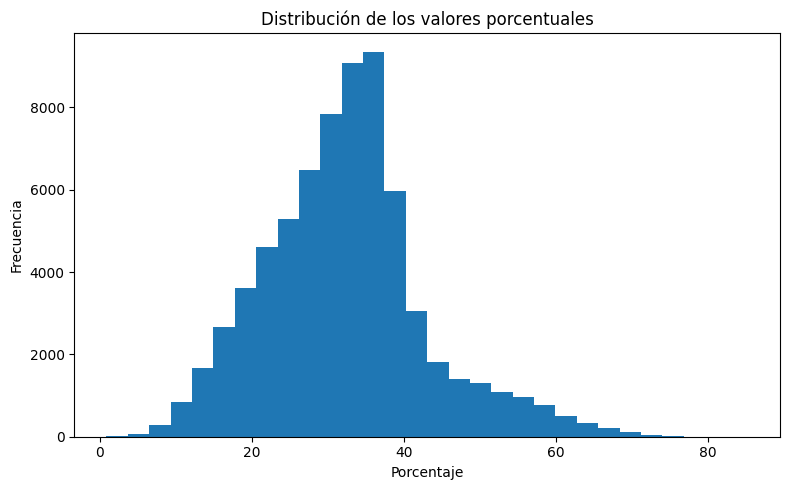

In [7]:
plt.figure(figsize=(8, 5))

plt.hist(df["Data_Value"], bins=30)

plt.title("Distribución de los valores porcentuales")
plt.xlabel("Porcentaje")
plt.ylabel("Frecuencia")

plt.tight_layout()
plt.show()

**2. Diagrama de caja para detectar valores atípicos**

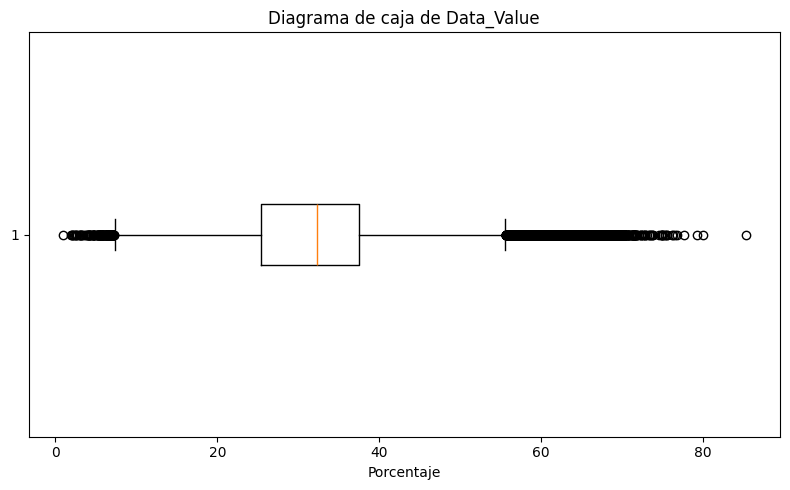

In [8]:
plt.figure(figsize=(8, 5))

plt.boxplot(df["Data_Value"], vert=False)

plt.title("Diagrama de caja de Data_Value")
plt.xlabel("Porcentaje")

plt.tight_layout()
plt.show()

**3. Promedio por indicador de salud**

/tmp/ipykernel_402/827961459.py:11: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


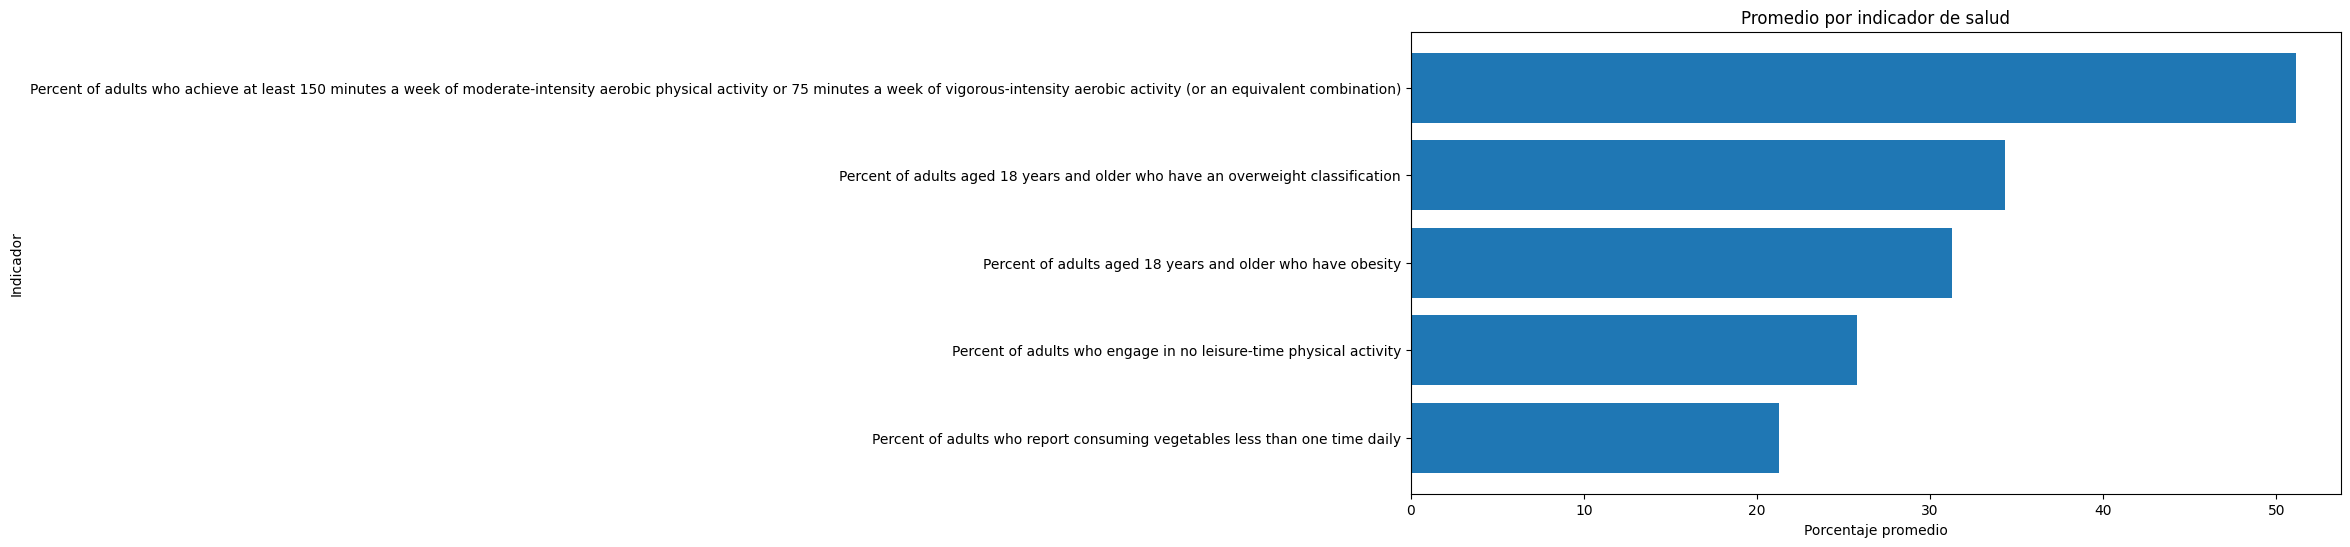

In [9]:
promedio_indicador = df.groupby("Question")["Data_Value"].mean().sort_values()

plt.figure(figsize=(12, 6))

plt.barh(promedio_indicador.index, promedio_indicador.values)

plt.title("Promedio por indicador de salud")
plt.xlabel("Porcentaje promedio")
plt.ylabel("Indicador")

plt.tight_layout()
plt.show()

**4. Top 10 estados con mayor obesidad**

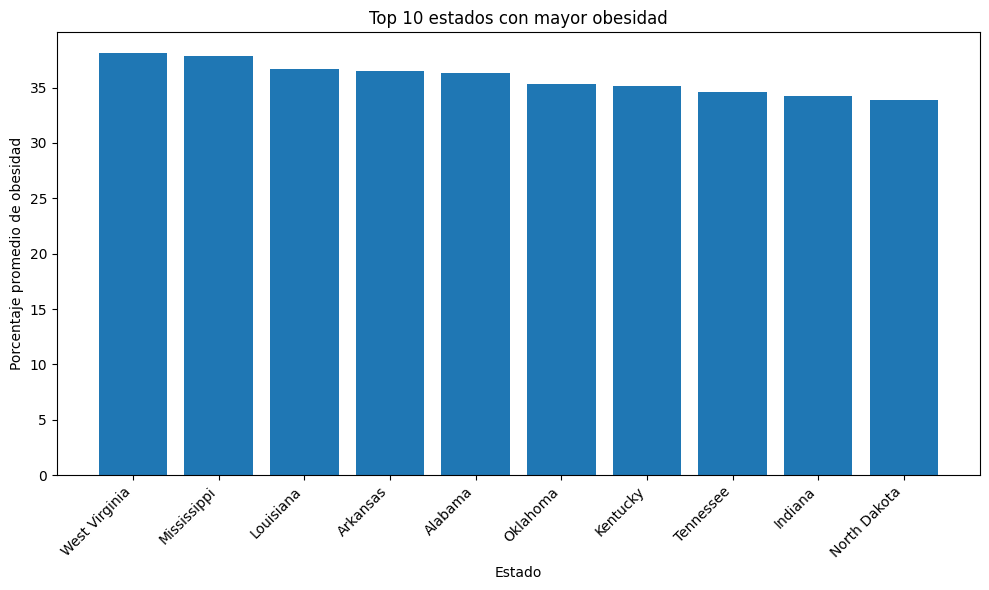

In [10]:
pregunta_obesidad = "Percent of adults aged 18 years and older who have obesity"

df_obesidad = df[df["Question"] == pregunta_obesidad]

top_obesidad = (
    df_obesidad
    .groupby("LocationDesc")["Data_Value"]
    .mean()
    .sort_values(ascending=False)
    .head(10)
)

plt.figure(figsize=(10, 6))

plt.bar(top_obesidad.index, top_obesidad.values)

plt.title("Top 10 estados con mayor obesidad")
plt.xlabel("Estado")
plt.ylabel("Porcentaje promedio de obesidad")

plt.xticks(rotation=45, ha="right")

plt.tight_layout()
plt.show()

**Matriz de correlación**

In [11]:
print("\n================ MATRIZ DE CORRELACIÓN ================\n")

correlacion = df[
    [
        "Data_Value",
        "Low_Confidence_Limit",
        "High_Confidence_Limit"
    ]
].corr()

print(correlacion)


================ MATRIZ DE CORRELACIÓN ================

                       Data_Value  Low_Confidence_Limit  High_Confidence_Limit
Data_Value               1.000000              0.959720               0.946402
Low_Confidence_Limit     0.959720              1.000000               0.819581
High_Confidence_Limit    0.946402              0.819581               1.000000


Resumen estadístico

In [12]:
print("\n================ RESUMEN ESTADÍSTICO ================\n")

print("Promedio general:", round(df["Data_Value"].mean(),2))
print("Mediana:", round(df["Data_Value"].median(),2))
print("Valor mínimo:", round(df["Data_Value"].min(),2))
print("Valor máximo:", round(df["Data_Value"].max(),2))
print("Desviación estándar:", round(df["Data_Value"].std(),2))


================ RESUMEN ESTADÍSTICO ================

Promedio general: 32.32
Mediana: 32.3
Valor mínimo: 0.9
Valor máximo: 85.3
Desviación estándar: 10.66


In [13]:
print("\n================ PROMEDIO POR INDICADOR ================\n")

print(
    df.groupby("Question")["Data_Value"]
      .mean()
      .sort_values(ascending=False)
)


================ PROMEDIO POR INDICADOR ================

Question
Percent of adults who achieve at least 150 minutes a week of moderate-intensity aerobic physical activity or 75 minutes a week of vigorous-intensity aerobic activity (or an equivalent combination)    51.165350
Percent of adults aged 18 years and older who have an overweight classification                                                                                                                         34.348726
Percent of adults aged 18 years and older who have obesity                                                                                                                                              31.265405
Percent of adults who engage in no leisure-time physical activity                                                                                                                                       25.789191
Percent of adults who report consuming vegetables less than one time daily                  

*****guardar tablas para dashbord

In [14]:
promedio_indicador.to_csv(
    "promedio_por_indicador.csv",
    index=True
)

top_obesidad.to_csv(
    "top_10_obesidad.csv",
    index=True
)

print("\nArchivos generados correctamente.")
print("• promedio_por_indicador.csv")
print("• top_10_obesidad.csv")


Archivos generados correctamente.
• promedio_por_indicador.csv
• top_10_obesidad.csv


##DASHBOARD

In [15]:
!pip -q install dash flask plotly

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.9/8.9 MB 72.1 MB/s eta 0:00:00


In [16]:
import pandas as pd
import numpy as np

try:
    df_dashboard = df.copy()
    print("Usando el DataFrame 'df' cargado previamente en el notebook.")
except NameError:
    df_dashboard = pd.read_csv("brfss_nutrition_clean.csv")
    print("No se encontró 'df'. Se cargó brfss_nutrition_clean.csv.")


for col in ["Data_Value", "Low_Confidence_Limit", "High_Confidence_Limit", "YearStart"]:
    if col in df_dashboard.columns:
        df_dashboard[col] = pd.to_numeric(df_dashboard[col], errors="coerce")

df_dashboard = df_dashboard.dropna(subset=["Question", "LocationDesc", "Data_Value", "YearStart"])

if "StratificationCategory1" in df_dashboard.columns:
    df_dashboard["StratificationCategory1"] = df_dashboard["StratificationCategory1"].fillna("General")
else:
    df_dashboard["StratificationCategory1"] = "General"

if "Stratification1" in df_dashboard.columns:
    df_dashboard["Stratification1"] = df_dashboard["Stratification1"].fillna("Total")
else:
    df_dashboard["Stratification1"] = "Total"

question_options = sorted(df_dashboard["Question"].dropna().unique())
years = sorted(df_dashboard["YearStart"].dropna().astype(int).unique())

print("Dataset listo para el dashboard:", df_dashboard.shape)
print("Indicadores disponibles:", len(question_options))
print("Años disponibles:", years)


Usando el DataFrame 'df' cargado previamente en el notebook.
Dataset listo para el dashboard: (69424, 12)
Indicadores disponibles: 5
Años disponibles: [np.int64(2011), np.int64(2012), np.int64(2013), np.int64(2014), np.int64(2015), np.int64(2016), np.int64(2017), np.int64(2018), np.int64(2019), np.int64(2020), np.int64(2021), np.int64(2022), np.int64(2023), np.int64(2024)]


In [17]:
from flask import Flask
from dash import Dash, dcc, html, Input, Output, dash_table
import plotly.express as px
import plotly.graph_objects as go
import pandas as pd
import numpy as np

CARD_STYLE = {
    "backgroundColor": "white",
    "padding": "16px",
    "borderRadius": "14px",
    "boxShadow": "0 2px 10px rgba(0,0,0,0.08)",
    "border": "1px solid #e8e8e8"
}

FILTER_STYLE = {
    "backgroundColor": "white",
    "padding": "18px",
    "borderRadius": "14px",
    "boxShadow": "0 2px 10px rgba(0,0,0,0.08)",
    "border": "1px solid #e8e8e8",
    "marginBottom": "18px"
}

GRAPH_STYLE = {
    "backgroundColor": "white",
    "padding": "10px",
    "borderRadius": "14px",
    "boxShadow": "0 2px 10px rgba(0,0,0,0.08)",
    "border": "1px solid #e8e8e8"
}

def recortar_texto(texto, limite=70):
    texto = str(texto)
    return texto if len(texto) <= limite else texto[:limite] + "..."


def figura_vacia(titulo, mensaje="No hay datos suficientes con los filtros seleccionados"):
    fig = go.Figure()
    fig.update_layout(
        title=titulo,
        template="plotly_white",
        height=390,
        annotations=[
            dict(
                text=mensaje,
                x=0.5,
                y=0.5,
                xref="paper",
                yref="paper",
                showarrow=False,
                font=dict(size=15)
            )
        ]
    )
    return fig


def aplicar_filtros(indicador, categoria, rango_anios):
    datos = df_dashboard.copy()

    if indicador:
        datos = datos[datos["Question"] == indicador]

    if categoria:
        datos = datos[datos["StratificationCategory1"] == categoria]

    if rango_anios and len(rango_anios) == 2:
        datos = datos[
            (datos["YearStart"] >= rango_anios[0]) &
            (datos["YearStart"] <= rango_anios[1])
        ]

    return datos

server = Flask(__name__)
app = Dash(__name__, server=server)
app.title = "Dashboard BRFSS Nutrition"

primer_indicador = question_options[0] if question_options else None
categorias_iniciales = sorted(
    df_dashboard[df_dashboard["Question"] == primer_indicador]["StratificationCategory1"].dropna().unique()
) if primer_indicador else sorted(df_dashboard["StratificationCategory1"].dropna().unique())

categoria_inicial = "Total" if "Total" in categorias_iniciales else (categorias_iniciales[0] if categorias_iniciales else None)
anio_min = int(min(years)) if years else 2011
anio_max = int(max(years)) if years else 2012

app.layout = html.Div(
    style={
        "backgroundColor": "#f5f7fb",
        "fontFamily": "Arial, sans-serif",
        "padding": "26px"
    },
    children=[
        html.Div([
            html.H1(
                "Dashboard de Indicadores de Nutrición y Actividad Física",
                style={"marginBottom": "6px", "color": "#1f2937"}
            ),
        ]),

        html.Div(
            style=FILTER_STYLE,
            children=[
                html.H3("Controles del dashboard", style={"marginTop": "0", "color": "#1f2937"}),
                html.Div(
                    style={"display": "grid", "gridTemplateColumns": "2fr 1fr 1fr", "gap": "18px"},
                    children=[
                        html.Div([
                            html.Label("Indicador de salud", style={"fontWeight": "bold"}),
                            dcc.Dropdown(
                                id="indicador-dropdown",
                                options=[{"label": recortar_texto(q, 95), "value": q} for q in question_options],
                                value=primer_indicador,
                                clearable=False
                            )
                        ]),
                        html.Div([
                            html.Label("Categoría", style={"fontWeight": "bold"}),
                            dcc.Dropdown(
                                id="categoria-dropdown",
                                options=[{"label": c, "value": c} for c in categorias_iniciales],
                                value=categoria_inicial,
                                clearable=False
                            )
                        ]),
                        html.Div([
                            html.Label("Rango de años", style={"fontWeight": "bold"}),
                            dcc.RangeSlider(
                                id="anio-slider",
                                min=anio_min,
                                max=anio_max,
                                step=1,
                                value=[anio_min, anio_max],
                                marks={str(y): str(y) for y in years},
                                allowCross=False
                            )
                        ])
                    ]
                )
            ]
        ),

        html.Div(
            style={"display": "grid", "gridTemplateColumns": "repeat(4, 1fr)", "gap": "16px", "marginBottom": "18px"},
            children=[
                html.Div([html.H4("Registros", style={"margin": "0", "color": "#6b7280"}), html.H2(id="kpi-registros", style={"margin": "4px 0 0"})], style=CARD_STYLE),
                html.Div([html.H4("Promedio", style={"margin": "0", "color": "#6b7280"}), html.H2(id="kpi-promedio", style={"margin": "4px 0 0"})], style=CARD_STYLE),
                html.Div([html.H4("Mediana", style={"margin": "0", "color": "#6b7280"}), html.H2(id="kpi-mediana", style={"margin": "4px 0 0"})], style=CARD_STYLE),
                html.Div([html.H4("Desviación estándar", style={"margin": "0", "color": "#6b7280"}), html.H2(id="kpi-desviacion", style={"margin": "4px 0 0"})], style=CARD_STYLE)
            ]
        ),

        html.Div(
            id="interpretacion",
            style={
                "backgroundColor": "#eef2ff",
                "border": "1px solid #c7d2fe",
                "padding": "14px 18px",
                "borderRadius": "14px",
                "color": "#1e3a8a",
                "marginBottom": "18px"
            }
        ),

        html.Div(
            style={"display": "grid", "gridTemplateColumns": "1fr 1fr", "gap": "18px", "marginBottom": "18px"},
            children=[
                html.Div(dcc.Graph(id="grafica-distribucion"), style=GRAPH_STYLE),
                html.Div(dcc.Graph(id="grafica-caja"), style=GRAPH_STYLE),
                html.Div(dcc.Graph(id="grafica-top-estados"), style=GRAPH_STYLE),
                html.Div(dcc.Graph(id="grafica-tendencia"), style=GRAPH_STYLE)
            ]
        ),

        html.Div(
            style=GRAPH_STYLE,
            children=[
                html.H3("Tabla resumen: Top 10 ubicaciones", style={"marginTop": "0", "color": "#1f2937"}),
                dash_table.DataTable(
                    id="tabla-resumen",
                    page_size=10,
                    style_table={"overflowX": "auto"},
                    style_cell={"textAlign": "left", "padding": "8px", "fontFamily": "Arial", "fontSize": "13px"},
                    style_header={"fontWeight": "bold", "backgroundColor": "#f3f4f6"}
                )
            ]
        )
    ]
)

@app.callback(
    Output("categoria-dropdown", "options"),
    Output("categoria-dropdown", "value"),
    Input("indicador-dropdown", "value")
)
def actualizar_categorias(indicador):
    datos = df_dashboard[df_dashboard["Question"] == indicador] if indicador else df_dashboard
    categorias = sorted(datos["StratificationCategory1"].dropna().unique())
    valor = "Total" if "Total" in categorias else (categorias[0] if categorias else None)
    return [{"label": c, "value": c} for c in categorias], valor

@app.callback(
    Output("kpi-registros", "children"),
    Output("kpi-promedio", "children"),
    Output("kpi-mediana", "children"),
    Output("kpi-desviacion", "children"),
    Output("interpretacion", "children"),
    Output("grafica-distribucion", "figure"),
    Output("grafica-caja", "figure"),
    Output("grafica-top-estados", "figure"),
    Output("grafica-tendencia", "figure"),
    Output("tabla-resumen", "data"),
    Output("tabla-resumen", "columns"),
    Input("indicador-dropdown", "value"),
    Input("categoria-dropdown", "value"),
    Input("anio-slider", "value")
)
def actualizar_dashboard(indicador, categoria, rango_anios):
    datos = aplicar_filtros(indicador, categoria, rango_anios)

    if datos.empty:
        vacia = figura_vacia("Sin datos")
        return "0", "N/A", "N/A", "N/A", "No hay datos para los filtros seleccionados.", vacia, vacia, vacia, vacia, [], []

    registros = f"{len(datos):,}"
    promedio = f"{datos['Data_Value'].mean():.2f}%"
    mediana = f"{datos['Data_Value'].median():.2f}%"
    desviacion = f"{datos['Data_Value'].std():.2f}"

    ubicacion_prom = datos.groupby("LocationDesc")["Data_Value"].mean().sort_values(ascending=False)
    mayor_ubicacion = ubicacion_prom.index[0]
    mayor_valor = ubicacion_prom.iloc[0]
    menor_ubicacion = ubicacion_prom.index[-1]
    menor_valor = ubicacion_prom.iloc[-1]

    interpretacion = (
        f"Interpretación rápida: para la categoría '{categoria}', la ubicación con mayor promedio es "
        f"{mayor_ubicacion} ({mayor_valor:.2f}%), mientras que la menor es "
        f"{menor_ubicacion} ({menor_valor:.2f}%). El promedio general filtrado es {datos['Data_Value'].mean():.2f}%."
    )

    titulo_corto = recortar_texto(indicador, 75)

    fig_distribucion = px.histogram(
        datos,
        x="Data_Value",
        nbins=30,
        marginal="box",
        title=f"Distribución de valores porcentuales<br><sup>{titulo_corto}</sup>",
        labels={"Data_Value": "Porcentaje", "count": "Frecuencia"}
    )
    fig_distribucion.update_layout(template="plotly_white", height=390)

    grupos_ordenados = datos.groupby("Stratification1")["Data_Value"].median().sort_values(ascending=False).index.tolist()
    if len(grupos_ordenados) > 12:
        grupos_ordenados = grupos_ordenados[:12]
        datos_box = datos[datos["Stratification1"].isin(grupos_ordenados)]
    else:
        datos_box = datos

    fig_caja = px.box(
        datos_box,
        x="Data_Value",
        y="Stratification1",
        category_orders={"Stratification1": grupos_ordenados},
        title="Comparación por grupo de estratificación",
        labels={"Data_Value": "Porcentaje", "Stratification1": "Grupo"}
    )
    fig_caja.update_layout(template="plotly_white", height=390)

    top_estados = (
        datos.groupby("LocationDesc", as_index=False)["Data_Value"]
        .mean()
        .sort_values("Data_Value", ascending=False)
        .head(10)
    )
    fig_top = px.bar(
        top_estados.sort_values("Data_Value"),
        x="Data_Value",
        y="LocationDesc",
        orientation="h",
        title="Top 10 ubicaciones con mayor promedio",
        labels={"Data_Value": "Porcentaje promedio", "LocationDesc": "Ubicación"},
        text="Data_Value"
    )
    fig_top.update_traces(texttemplate="%{text:.2f}%", textposition="outside")
    fig_top.update_layout(template="plotly_white", height=390, margin=dict(l=20, r=30, t=55, b=35))

    tendencia = (
        datos.groupby(["YearStart", "Stratification1"], as_index=False)["Data_Value"]
        .mean()
        .sort_values("YearStart")
    )

    principales_grupos = datos["Stratification1"].value_counts().head(6).index.tolist()
    tendencia = tendencia[tendencia["Stratification1"].isin(principales_grupos)]

    fig_tendencia = px.line(
        tendencia,
        x="YearStart",
        y="Data_Value",
        color="Stratification1",
        markers=True,
        title="Tendencia anual del indicador seleccionado",
        labels={"YearStart": "Año", "Data_Value": "Porcentaje promedio", "Stratification1": "Grupo"}
    )
    fig_tendencia.update_layout(template="plotly_white", height=390)

    tabla = (
        datos.groupby("LocationDesc", as_index=False)
        .agg(
            Promedio=("Data_Value", "mean"),
            Mediana=("Data_Value", "median"),
            Minimo=("Data_Value", "min"),
            Maximo=("Data_Value", "max"),
            Registros=("Data_Value", "count")
        )
        .sort_values("Promedio", ascending=False)
        .head(10)
    )

    for col in ["Promedio", "Mediana", "Minimo", "Maximo"]:
        tabla[col] = tabla[col].round(2)

    columnas = [{"name": c, "id": c} for c in tabla.columns]

    return registros, promedio, mediana, desviacion, interpretacion, fig_distribucion, fig_caja, fig_top, fig_tendencia, tabla.to_dict("records"), columnas

print("Dashboard intermedio creado correctamente.")
print("Ejecuta la siguiente celda para abrirlo en Google Colab.")


Dashboard intermedio creado correctamente.
Ejecuta la siguiente celda para abrirlo en Google Colab.


#DASHBOARD

In [18]:
from google.colab import output

PORT = 8052
output.serve_kernel_port_as_iframe(PORT, height=950)

app.run(
    host="0.0.0.0",
    port=PORT,
    debug=False,
    use_reloader=False
)


<IPython.core.display.Javascript object>

Dash is running on http://0.0.0.0:8052/



INFO:dash.dash:Dash is running on http://0.0.0.0:8052/



 * Serving Flask app '__main__'
 * Debug mode: off


INFO:werkzeug:WARNING: This is a development server. Do not use it in a production deployment. Use a production WSGI server instead.
 * Running on all addresses (0.0.0.0)
 * Running on http://127.0.0.1:8052
 * Running on http://172.28.0.12:8052
INFO:werkzeug:Press CTRL+C to quit
INFO:werkzeug:127.0.0.1 - - [06/Jul/2026 23:39:14] "GET / HTTP/1.1" 200 -
INFO:werkzeug:127.0.0.1 - - [06/Jul/2026 23:39:15] "GET /_dash-component-suites/dash/dash_table/bundle.v7_4_0m1783381148.js HTTP/1.1" 200 -
INFO:werkzeug:127.0.0.1 - - [06/Jul/2026 23:39:15] "GET /_dash-component-suites/dash/deps/react-dom@18.v4_4_0m1783381148.3.1.min.js HTTP/1.1" 200 -
INFO:werkzeug:127.0.0.1 - - [06/Jul/2026 23:39:15] "GET /_dash-component-suites/dash/deps/prop-types@15.v4_4_0m1783381148.8.1.min.js HTTP/1.1" 200 -
INFO:werkzeug:127.0.0.1 - - [06/Jul/2026 23:39:15] "GET /_dash-component-suites/dash/dcc/dash_core_components.v4_4_0m1783381148.js HTTP/1.1" 200 -
INFO:werkzeug:127.0.0.1 - - [06/Jul/2026 23:39:15] "GET /_dash